# Clasificando gestos musculares

## Cuatro gestos de la mano:
1. Piedra - 0

2. Tijera - 1

3. Papel - 2

4. Ok - 3


Nuestro objetivo es crear un clasificador que distinga correctamente entre estos 4 gestos, gestionando problemas como robustez al ruido y capacidad de generalización con múltiples sujetos.

In [50]:
# librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
import math

## Cargando datos

In [2]:
# 4 csvs (1 por clase) -> unirlos en 1

df_0 = pd.read_csv("data/0.csv", header=None)
df_1 = pd.read_csv("data/1.csv", header=None)
df_2 = pd.read_csv("data/2.csv", header=None)
df_3 = pd.read_csv("data/3.csv", header=None)


# última col -> label (65)
df = pd.concat([df_0, df_1, df_2, df_3], ignore_index=True)

In [30]:
np.mean(df_0.to_numpy()[:, :8], axis=0).shape

(8,)

In [39]:
df_0.shape

(2910, 65)

In [ ]:
np.array([np.mean(df_0.iloc[:, 0][i:i + 50]) for i in range((df_0.shape[0] // 50))])

[np.float64(0.9),
 np.float64(-0.28),
 np.float64(0.34),
 np.float64(0.72),
 np.float64(0.46),
 np.float64(0.66),
 np.float64(0.24),
 np.float64(0.4),
 np.float64(-0.16),
 np.float64(0.38),
 np.float64(1.68),
 np.float64(1.36),
 np.float64(1.58),
 np.float64(0.8),
 np.float64(1.3),
 np.float64(0.9),
 np.float64(1.3),
 np.float64(1.76),
 np.float64(3.3),
 np.float64(3.9),
 np.float64(3.26),
 np.float64(1.48),
 np.float64(1.28),
 np.float64(1.3),
 np.float64(1.66),
 np.float64(1.98),
 np.float64(1.84),
 np.float64(1.92),
 np.float64(1.64),
 np.float64(2.8),
 np.float64(1.5),
 np.float64(1.24),
 np.float64(0.58),
 np.float64(-0.88),
 np.float64(-0.28),
 np.float64(-0.64),
 np.float64(-0.06),
 np.float64(0.72),
 np.float64(-0.28),
 np.float64(0.38),
 np.float64(0.94),
 np.float64(2.3),
 np.float64(1.44),
 np.float64(2.22),
 np.float64(1.08),
 np.float64(1.4),
 np.float64(1.16),
 np.float64(1.12),
 np.float64(2.52),
 np.float64(1.8),
 np.float64(1.7),
 np.float64(1.96),
 np.float64(2.42),
 

In [45]:
np.arange(0, df_0.shape[0], 50)

array([   0,   50,  100,  150,  200,  250,  300,  350,  400,  450,  500,
        550,  600,  650,  700,  750,  800,  850,  900,  950, 1000, 1050,
       1100, 1150, 1200, 1250, 1300, 1350, 1400, 1450, 1500, 1550, 1600,
       1650, 1700, 1750, 1800, 1850, 1900, 1950, 2000, 2050, 2100, 2150,
       2200, 2250, 2300, 2350, 2400, 2450, 2500, 2550, 2600, 2650, 2700,
       2750, 2800, 2850, 2900])

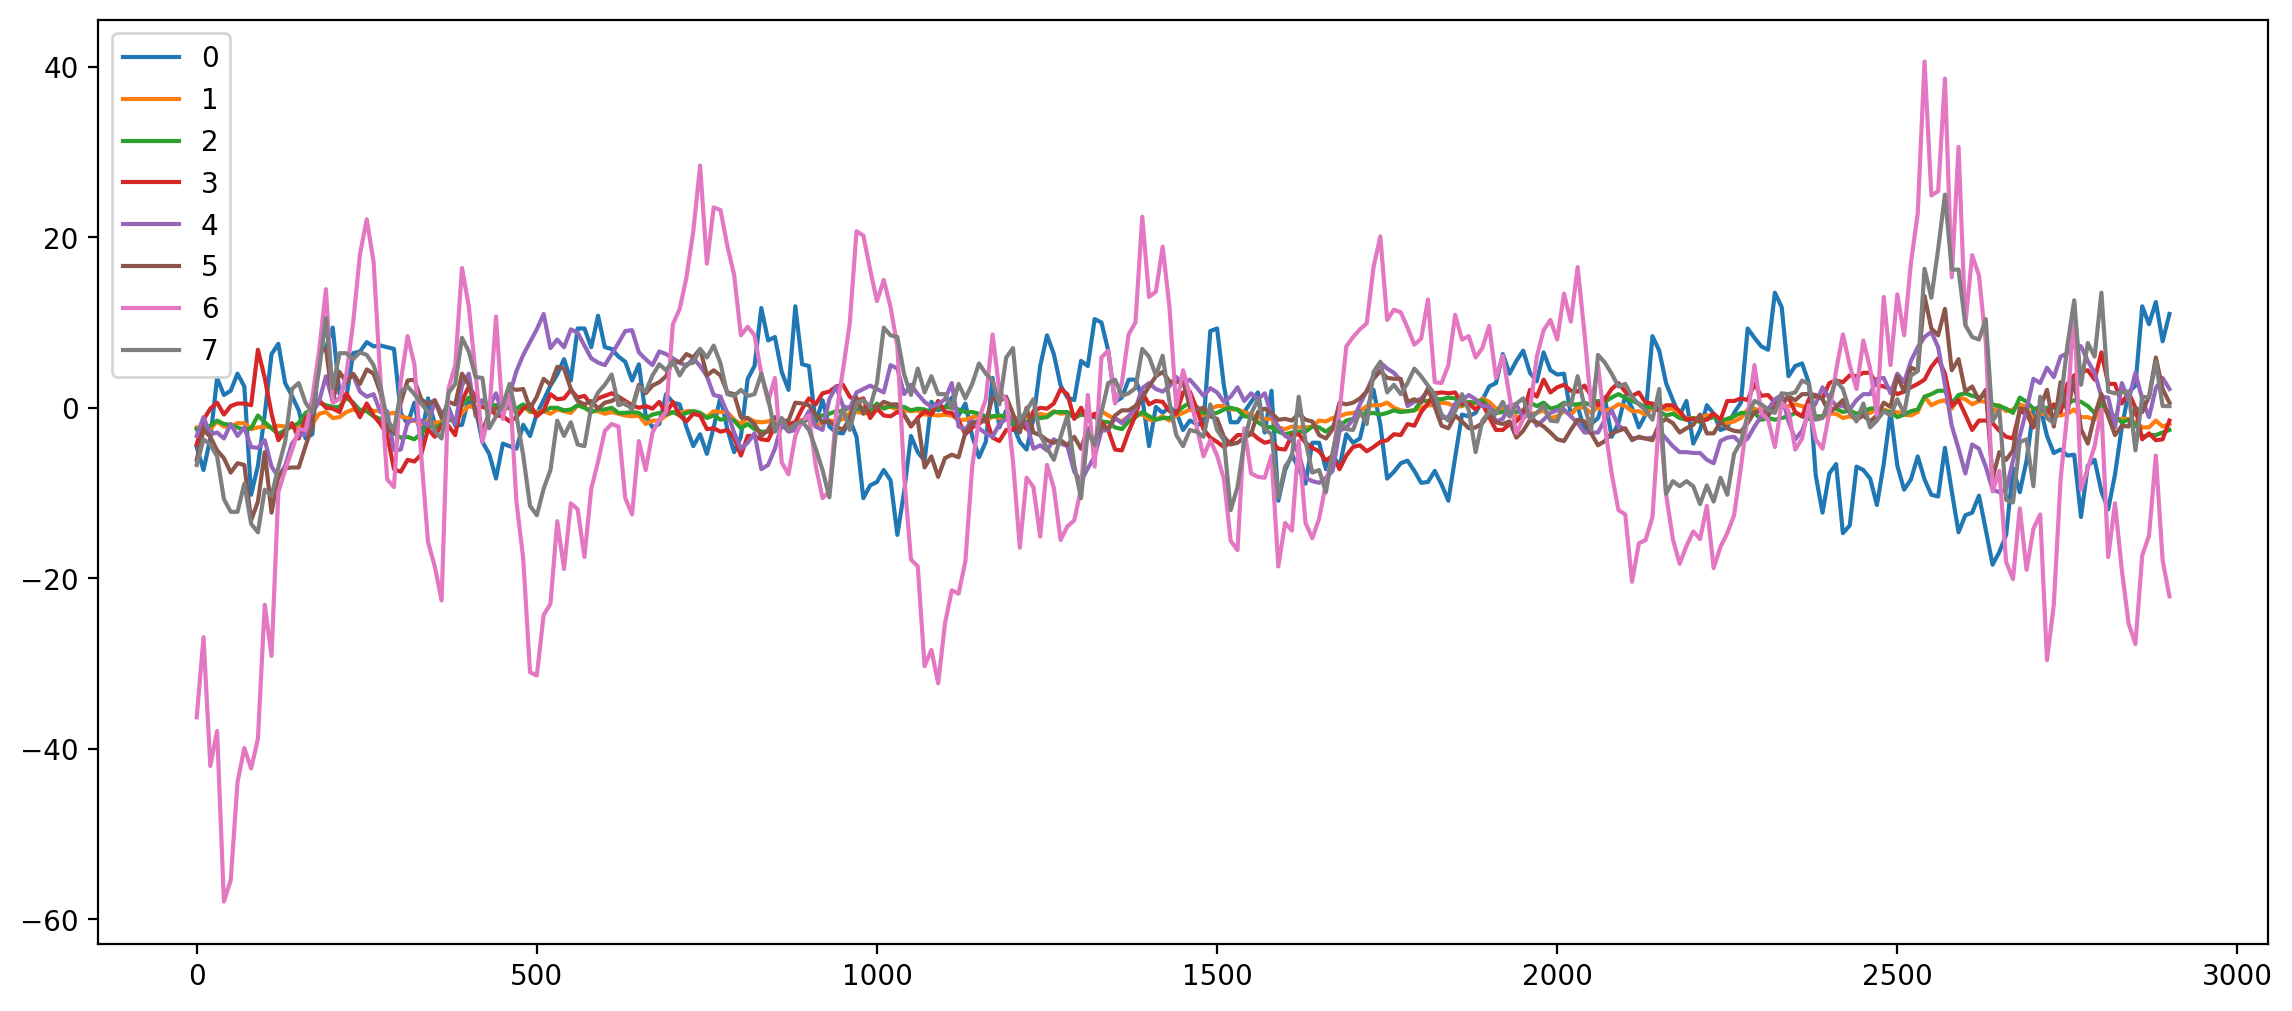

In [70]:
plt.figure(figsize=(14, 6), dpi=200)
window = 10
for i in range(8):
    # plt.plot(df_0.iloc[:, i])
    a = np.array([np.mean(df_0.iloc[:, i][j:j + window]) for j in range(math.floor(df_0.shape[0] / window))])
    plt.plot(np.arange(0, df_0.shape[0], window), a, label=f"{i}")

plt.legend()
plt.show()

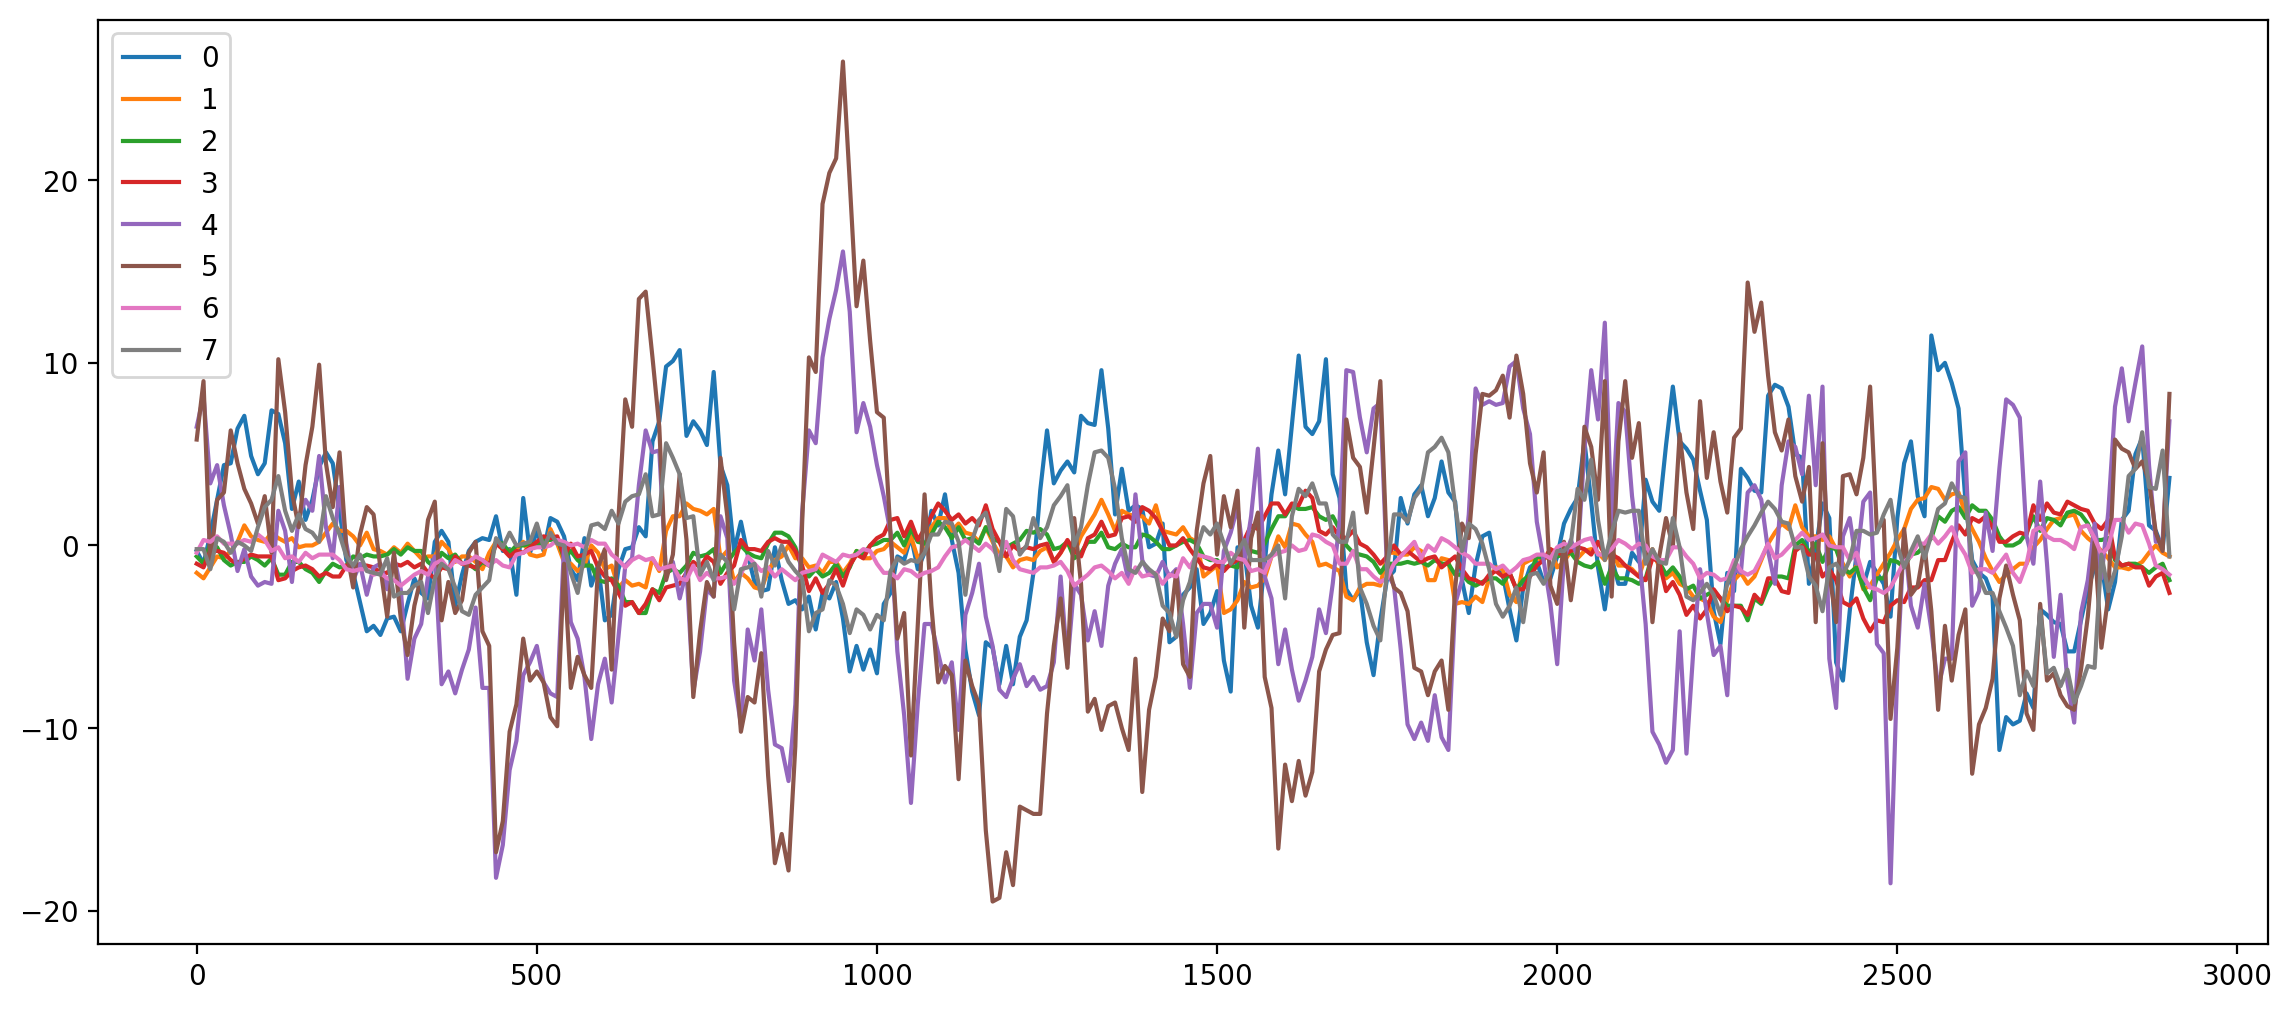

In [74]:
plt.figure(figsize=(14, 6), dpi=200)
window = 10
for i in range(8):
    # plt.plot(df_0.iloc[:, i])
    a = np.array([np.mean(df_1.iloc[:, i][j:j + window]) for j in range(math.floor(df_1.shape[0] / window) + 1)])
    plt.plot(np.arange(0, df_1.shape[0], window), a, label=f"{i}")

plt.legend()
plt.show()

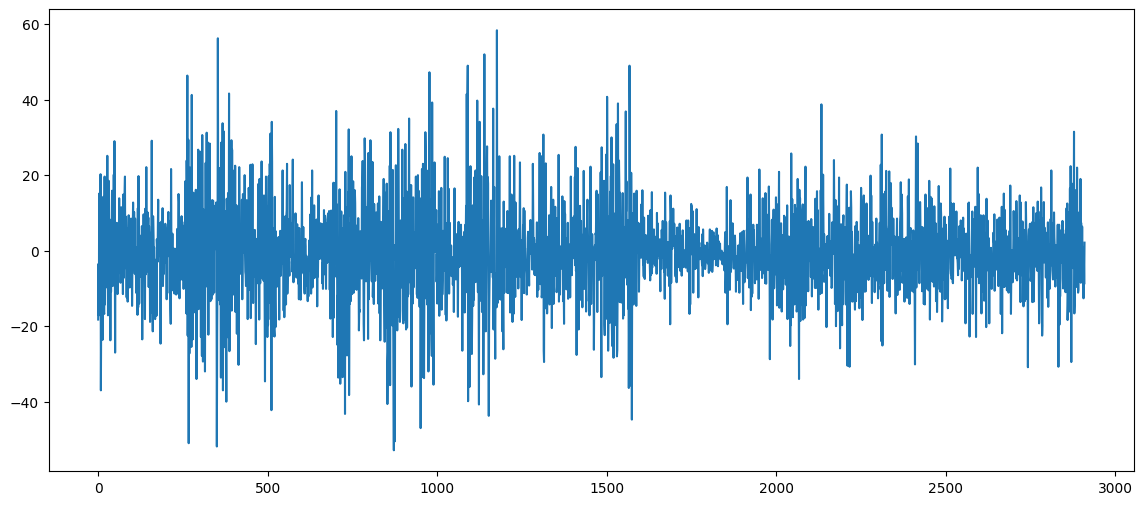

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(np.mean(df_0.to_numpy()[:, :8], axis=1))
plt.show()

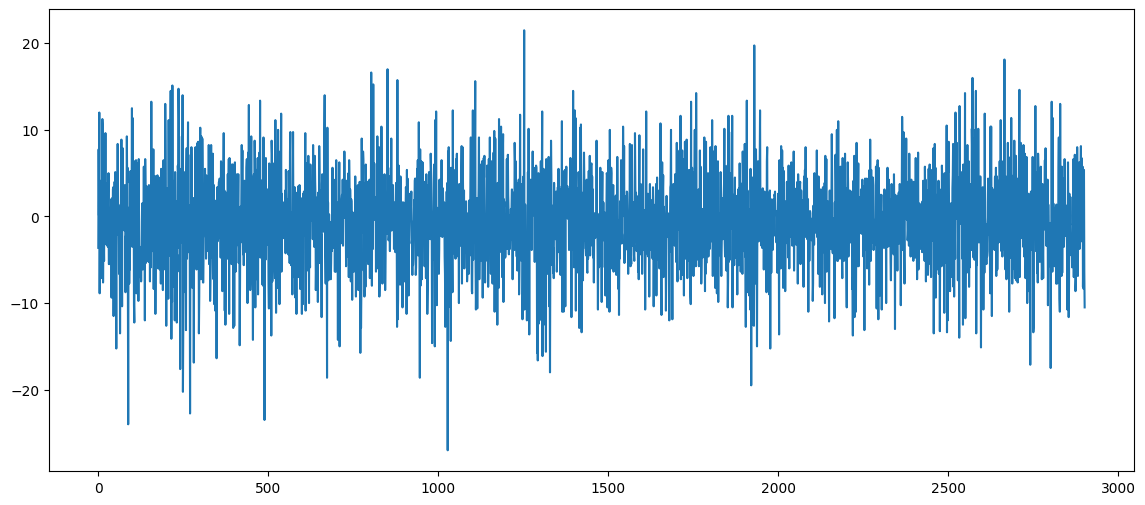

In [68]:
plt.figure(figsize=(14, 6))
plt.plot(np.mean(df_1.to_numpy()[:, :8], axis=1))
plt.show()

### Balance de clases

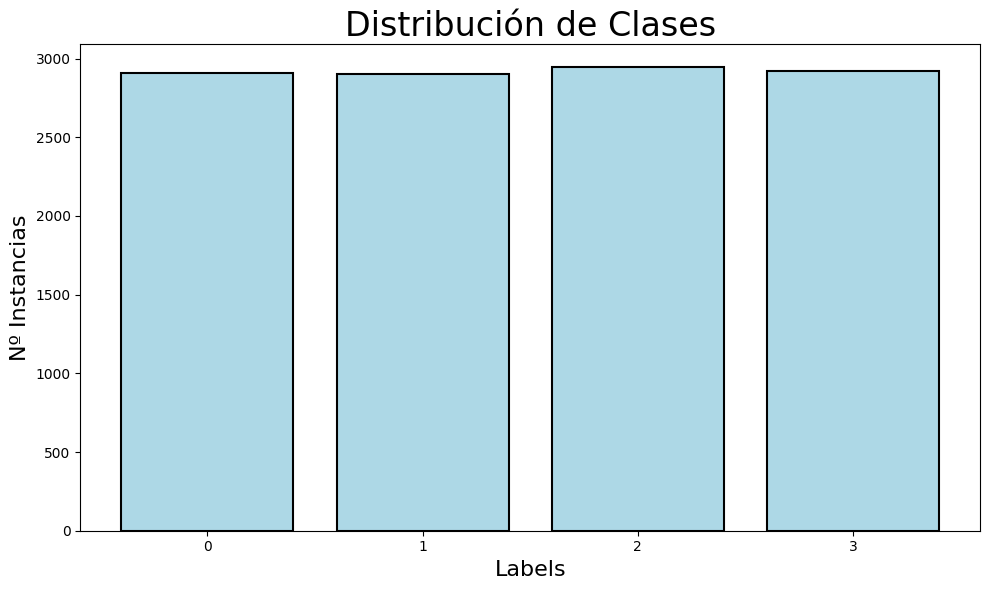

In [18]:
plt.figure(figsize=(10, 6))

instancias_por_clase = {"0" : len(df_0), # label : n_instancias
                        "1" : len(df_1),
                        "2" : len(df_2),
                        "3" : len(df_3)}

# bar plot
labels = instancias_por_clase.keys()
n_instancias = instancias_por_clase.values()
plt.bar(labels, n_instancias, edgecolor="black", lw=1.5, color="lightblue")
plt.title("Distribución de Clases", fontsize=24)
plt.xlabel("Labels", fontsize=16)
plt.ylabel("Nº Instancias", fontsize=16)
plt.tight_layout()
plt.show()

## Visualización

In [11]:
# separar características y labels
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

reducer = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    random_state=42,
    )
X_umap = reducer.fit_transform(X_scaled)

/home/jordi/Escritorio/uni/3/c2/Aprendizaje Avanzado/proyecto/entorno_proyecto/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


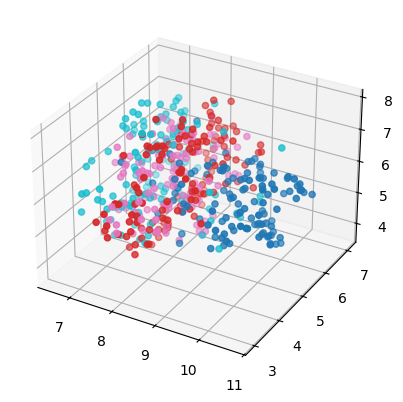

In [12]:
mask = np.random.choice(np.arange(len(X_umap)), size=500, replace=False)

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_umap[mask, 0], X_umap[mask, 1], X_umap[mask, 2], c=y[mask], cmap="tab10")
plt.show()

### Train / Test Splits

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)